# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
# Librerias de manejo de datos
import pandas as pd
# Librerias de visualizacion
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
# cargar archivos, cargamos todos los datos disponibles en variables
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)
#Solo se cuentan con 2 tipos de planes registrados

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)
# Analizar: ciudades con valor "?" y los churn_date como se estan ingresando, por que se estan guardando como NaN (NotANomber) en la tabla users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)
# no hay una relacion entre "call" - "length" y "text" - "duration", por lo tanto, se esta ingresando valores nulos NaN

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)# 2 filas (2 tipos de planes), 8 columnas
print("users", users.shape)# 4,000 usuarios registrados, 8 columnas
print("usage", usage.shape)# 40,000 registros de uso, 6 columnas y utiliza el user_id de la tabla users como FK.

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print('cantidad de nulos en cada atributo para users')
print(users.isna().sum())
print('Proporcion de nulos en cada atributo para users')
print(users.isna().mean())

cantidad de nulos en cada atributo para users
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporcion de nulos en cada atributo para users
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print('cantidad de nulos en cada atributo para usage')
print(usage.isna().sum())
print('Proporcion de nulos en cada atributo para usage')
print(usage.isna().mean())

cantidad de nulos en cada atributo para usage
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporcion de nulos en cada atributo para usage
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


In [12]:
# cantidad de nulos para plans
print('cantidad de nulos en cada atributo para plans')
print(plans.isna().sum())
print('Proporcion de nulos en cada atributo para plans')
print(plans.isna().mean())


cantidad de nulos en cada atributo para plans
plan_name            0
messages_included    0
gb_per_month         0
minutes_included     0
usd_monthly_pay      0
usd_per_gb           0
usd_per_message      0
usd_per_minute       0
dtype: int64
Proporcion de nulos en cada atributo para plans
plan_name            0.0
messages_included    0.0
gb_per_month         0.0
minutes_included     0.0
usd_monthly_pay      0.0
usd_per_gb           0.0
usd_per_message      0.0
usd_per_minute       0.0
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint: 
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
¿Qué columnas tienen valores faltantes y en qué proporción?
Indica qué harías: ¿imputar, eliminar, ignorar?
- En la tabla **users**, el atributo **churn_date** muestra un **88.35%** de datos nulos, con la falta de informacion/documentacion recomiendo **ignorar** ese atributo para el analisis y usarlo en el futuro.
- En la tabla **users**, en el atributo **city**, se tedectan campos con el simbolo **'?'**, un campo **dificil de imputar** con una proporcion del **11.72%,** por lo tanto, recomiendo **ignorar** o dejar como **nulo** para el analisis por ubicacion.
- En la tabla **usage**, dependiendo el tipo **text/call** se utiliza el atributo **duration** para call y **length** para text, lo que causa muchos datos nulos NaN, **55.19%** campos nulos en duration y **44.74%** en length, recomiendo **ignorar** un campo para cada caso en su analisis o generar una nueva tabla para el tipo de uso.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users.describe(include='number')# Solo para columnas numéricas (por defecto)

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` La variable user_id parece ser un **identificador secuencial.**
La media y los percentiles están perfectamente distribuidos, lo que indica:
No hay valores faltantes.
No hay valores atípicos.
Es una variable técnica (no analítica).
Conclusión: user_id funciona correctamente como identificador único.
- La columna `age` contiene valores inválidos (-999) que deben:
Reemplazarse por NaN: df["age"] = df["age"].replace(-999, pd.NA) 
O eliminarse antes de cualquier análisis o modelado
La mediana (47) es mayor que la media (33.7)
Esto sugiere una posible **asimetría negativa** causada por el -999
El rango intercuartílico (Q3-Q1) (63-32) indica que **la mayoría de usuarios están en edad adulta**
Antes de generar insights o KPIs, es necesario realizar data cleaning.

In [14]:
# explorar columnas numéricas de usage
usage.describe(include='number')# Solo para columnas numéricas (por defecto)

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` Ambas columnas son **identificadores técnicos:**
id parece ser el identificador único del evento o registro.
user_id corresponde al usuario asociado al evento.
No aportan valor analítico directo, pero:
Son clave para joins
Permiten agregaciones por usuario
Garantizan trazabilidad
👉 Conclusión: las columnas `id` y `user_id` son **variables estructurales, no predictivas.**
- La columna duration:
Existe una cantidad significativa de valores nulos (~55%) (más de 22,000 valores faltantes).
La media es mayor que la mediana → ligera asimetría positiva.
Hay valores extremos (hasta 120) que podrían ser outliers dependiendo del contexto.
👉 Indica posible sesgo hacia duraciones cortas con algunos eventos largos aislados.
- La columna length:
También presenta una cantidad importante de nulos (~45% valores faltantes).
La mediana está muy cerca de la media → distribución relativamente centrada.
El máximo de 1,490 sugiere presencia de valores extremos fuertes.

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` Existe un porcentaje relevante de valores faltantes (11.7%, 1-(3531/4000)), lo cual requiere análisis:
¿Error de captura?
¿Usuarios sin ubicación registrada?
¿Datos opcionales?
La distribución muestra concentración en Bogotá (22.8% del total válido 808/3531), lo que podría indicar:
Mayor penetración de mercado en esa ciudad
Posible sesgo geográfico en el dataset
👉 La variable city puede ser clave para:
Segmentación geográfica
Estrategias de marketing local
Análisis de churn o consumo por región
- La columna `plan` No hay valores nulos, lo que indica buena calidad de datos.
Existe una distribución desbalanceada:
65% Básico
35% otro plan (probablemente Premium)
👉 Para el negocio:
La mayoría de usuarios están en el plan básico.
Existe oportunidad potencial de upselling.
Es una variable clave para análisis de ingresos y comportamiento de uso.

In [16]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` presenta 40,000 registros sin valores faltantes y contiene 2 categorías: text y call. La categoría predominante es text, con 22,092 registros, lo que indica que aproximadamente el 55% de las interacciones corresponden a mensajes de texto. Esta distribución sugiere que el canal de texto es el medio de uso más frecuente dentro del dataset.

---
✍️ **Comentario**: Antes de cualquier análisis o modelado:

Identificar y tratar sentinels explícitos (-999).

Validar valores límite con reglas de negocio.

Recalcular estadísticas después de limpieza.

**Valores inválidos o sentinels**  
- users[age]
Se identificó el valor -999 como mínimo.
Este valor no es una edad válida.
Probablemente representa un sentinel value utilizado para indicar datos faltantes o no disponibles.

- usage[duration]
Presenta valores en 0.
Dependiendo del contexto del negocio, podría representar:
Evento fallido
Registro incompleto
Valor válido (por ejemplo, llamada sin duración efectiva)

- usage[length]
También contiene valores en 0.
Requiere validación con reglas de negocio para determinar si es válido o no.


**Acciones recomendadas**
🔹 1. age
Reemplazar -999 por NaN.
Evaluar si se imputará (media/mediana) o se excluirá en análisis.
```df["age"] = df["age"].replace(-999, pd.NA)```
🔹 2. duration y length
Validar con el área de negocio si 0 es valor válido.
Si representa error:
Convertir a NaN.
Si es válido:
Mantenerlo y analizar su proporción dentro del total.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [19]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.describe()

count    4000.000000
mean     2023.034000
std         0.866044
min      2022.000000
25%      2022.000000
50%      2023.000000
75%      2024.000000
max      2026.000000
Name: reg_date, dtype: float64

En `reg_date`, los 4,000 usuarios se han registrado desde el año 2022 hasta el año 2026

In [20]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year
usage['date'].dt.year.describe()

count    39950.0
mean      2024.0
std          0.0
min       2024.0
25%       2024.0
50%       2024.0
75%       2024.0
max       2024.0
Name: date, dtype: float64

En `date`, se han registrado 40,000 usos pero solo aparecen del año 2024

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- La mayoría de registros se concentran entre 2022 y 2024.
- La media cercana a 2023 confirma que el dataset es reciente.
- La desviación estándar baja (0.86) indica poca dispersión, lo cual es consistente con un rango corto de años.
- Sin embargo, la presencia de 2026 es un outlier temporal.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
# Calcular mediana sin considerar -999
median_age = users.loc[users['age'] != -999, 'age'].median()
# Reemplazar sentinels
users['age'] =  users['age'].replace(-999, median_age)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [23]:
# Marcar fechas futuras como NA para reg_date
# Definir límite de año permitido
year_limit = 2024

# Marcar fechas futuras como NA
users.loc[
    users['reg_date'].dt.year > year_limit,
    'reg_date'
] = pd.NaT

# Verificar cambios
users.tail(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
3995,13995,Ana,Lopez,60.0,Medellín,2024-12-29 21:42:48.342085520,Basico,NaN
3996,13996,Carlos,Ramirez,24.0,Medellín,2024-12-30 04:17:06.256564144,Premium,NaN
3997,13997,Ana,Lopez,58.0,Bogotá,2024-12-30 10:51:24.171042768,Premium,NaN
3998,13998,Mariana,Lopez,57.0,Bogotá,2024-12-30 17:25:42.085521392,Basico,NaN
3999,13999,Ana,Lopez,20.0,Bogotá,2024-12-31 00:00:00.000000000,Basico,NaN


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
# verificamos el promedio de valores faltantes dependiendo el tipo call/text
usage.groupby("type")["duration"].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [25]:
# Verificación MAR en usage (Missing At Random) para length
# verificamos el promedio de valores faltantes dependiendo el tipo call/text
usage.groupby("type")["length"].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Los valores nulos en duration y length están condicionados por el tipo de interacción (type), lo que indica un patrón estructural consistente con el negocio. 
Si los nulos dependen completamente de type, entonces:

✔️ No son errores

✔️ No son aleatorios

✔️ Son estructurales

Esto es un caso típico de **Missing At Random** condicionado a otra variable observada.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    # renombrar columnas
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")

).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
# usamos un leftjoin para conservar todos los usuarios. Si algún usuario no tiene actividad, quedará con NaN
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile.describe(include="number")
'''Perfil Demográfico

Edad media: 48 años

Rango: 18 a 79 años

50% de los usuarios están entre 33 y 63 años

Interpretación Gerencial

Nuestra base está concentrada en adultos económicamente activos.
No somos una base predominantemente joven.

Oportunidad:
Podríamos diseñar estrategias diferenciadas:

Plan digital / data-first para <35 años

Plan con beneficios tradicionales para >50 años'''

'Perfil Demográfico\n\nEdad media: 48 años\n\nRango: 18 a 79 años\n\n50% de los usuarios están entre 33 y 63 años\n\nInterpretación Gerencial\n\nNuestra base está concentrada en adultos económicamente activos.\nNo somos una base predominantemente joven.\n\nOportunidad:\nPodríamos diseñar estrategias diferenciadas:\n\nPlan digital / data-first para <35 años\n\nPlan con beneficios tradicionales para >50 años'

In [29]:
# Distribución porcentual del tipo de plan
plans.value_counts(normalize=True)
#El salto de precio es +108% (12 → 25 USD)
#Pero el beneficio es:
#5x mensajes
#4x datos
#6x minutos

#Objetivamente Premium es mucho mejor valor por dólar.
#El problema no es el valor.
#El problema es la percepción del salto de precio.

#Objetivo: Aumentar migración a Premium
#Tenemos que reducir la fricción psicológica del salto de $12 → $25.
#Creando promociones o otro tipo de plan intermedio.

plan_name  messages_included  gb_per_month  minutes_included  usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute
Basico     100                5             100               12               1.2         0.08             0.10              0.5
Premium    500                20            600               25               1.0         0.05             0.07              0.5
dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

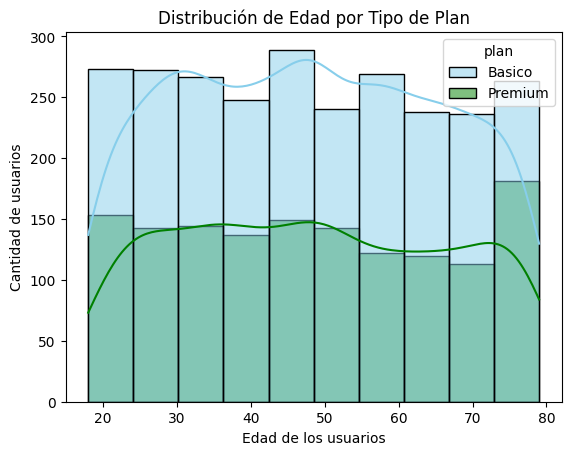

In [30]:
# Histograma para visualizar la edad (age)
sb.histplot(
    data=users,
    x="age",
    bins=10,
    hue="plan",
    palette=['skyblue','green'],
    kde=True
)
# Metadata de la grafica
plt.title("Distribución de Edad por Tipo de Plan")
plt.xlabel('Edad de los usuarios')
plt.ylabel('Cantidad de usuarios')
#plt.legend(title="Plan")
plt.show()


💡Insights: 
- Dentro del plan Premium, hay un ligero incremento de proporción en usuarios entre la edad de 70-80 años. Deberíamos de enfocarnos en atraer personas mayores de 40-50 años al plan Premium para que nuestra grafica en vez de tener una distribución simétrica, sea sesgada a la izquierda, para tener mejores ganancias.
- Dentro del plan Básico, tenemos un pico de usuarios de edad 40-50, con una distribución simétrica, y tenemos más usuarios jóvenes entre 20-35 años a comparación de los usuarios entre 50-70 años, necesitamos que la gráfica crezca para tener un sesgo a la derecha, con más usuarios jóvenes y después hacer la transición al plan Premium con un sesgo a la izquierda a futuro.

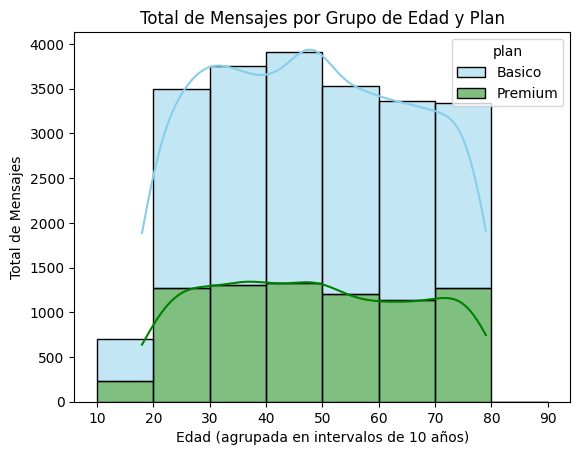

In [31]:
#  Crear grupos de edad en intervalos de 10 años
# ---------------------------------------------------------
# Utilizamos pd.cut() para segmentar la variable 'age'
# en rangos de 10 años:
# [10-20), [20-30), ..., [80-90)
# right=False indica que el límite derecho no se incluye.
user_profile["grupo_edad"] = pd.cut(
    user_profile["age"],
    bins=range(10, 91, 10),   # Intervalos de 10 años
    right=False               # Intervalos cerrados por la izquierda
)

#  Agrupar por grupo de edad y tipo de plan
# ---------------------------------------------------------
# Agrupamos los usuarios por:
# - grupo_edad
# - plan (Básico o Premium)
#
# Luego sumamos las métricas de uso:
# - cant_mensajes
# - cant_llamadas
# - cant_minutos_llamada
#
# Finalmente usamos reset_index() para convertir
# los índices del groupby en columnas normales.

edad_plan_agg = (
    user_profile
    .groupby(["grupo_edad", "plan"])[
        ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
    ]
    .sum()              # Suma total de uso por grupo
    .reset_index()      # Devuelve estructura tabular estándar
)
# Histograma para visualizar la cant_mensajes
sb.histplot(
    data=user_profile,
    x="age",
    weights="cant_mensajes",      # suma mensajes en cada bin
    bins=range(10, 91, 10),       # intervalos de 10 años
    hue="plan",
    palette=['skyblue','green'],
    multiple="stack",             # opcional: apila los planes
    kde=True
)

plt.title("Total de Mensajes por Grupo de Edad y Plan")
plt.xlabel("Edad (agrupada en intervalos de 10 años)")
plt.ylabel("Total de Mensajes")

plt.show()

💡Insights: 
- Notamos que el uso de mensajes en ambos planes se comporta la gráfica de manera simétrica, con un mayor uso de mensajes en el plan Básico con aprox. 3,8k mensajes.
- El rango de edad de las personas que más mandan mensajes son entre 40-50 años.

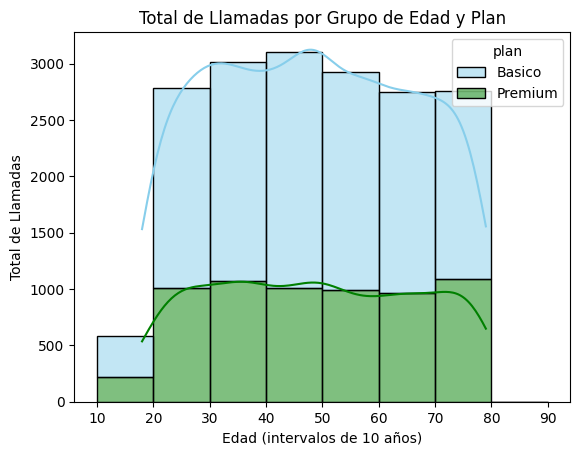

In [32]:
# Histograma para visualizar la cant_llamadas
sb.histplot(
    data=user_profile,
    x="age",
    weights="cant_llamadas",     # suma llamadas por bin
    bins=range(10, 91, 10),      # intervalos de 10 años
    hue="plan",
    palette=['skyblue','green'],
    multiple="stack",            # apila Básico y Premium
    kde=True
)

plt.title("Total de Llamadas por Grupo de Edad y Plan")
plt.xlabel("Edad (intervalos de 10 años)")
plt.ylabel("Total de Llamadas")

plt.show()

💡Insights: 
- Notamos que el uso de llamadas en ambos planes se comporta la gráfica de manera simétrica, con un mayor uso de llamadas en el plan Básico con aprox. 3,1k llamadas con un ligero incremento en el plan Premium en el rango de edad de entre 70-80 años.
- El rango de edad de las personas que más hacen llamadas son entre 40-50 años.

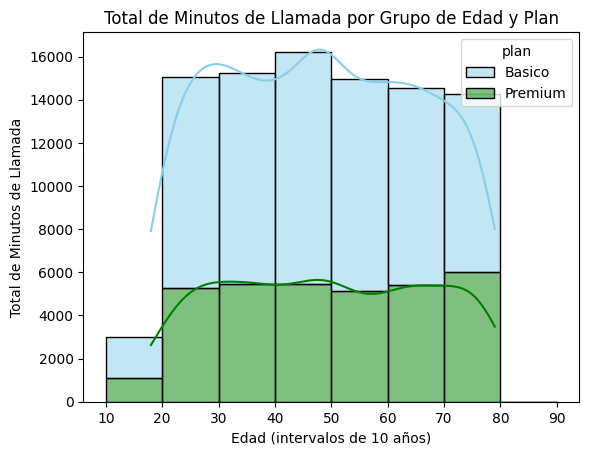

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sb.histplot(
    data=user_profile,
    x="age",
    weights="cant_minutos_llamada",   # suma minutos en cada rango de edad
    bins=range(10, 91, 10),           # intervalos de 10 años
    hue="plan",
    palette=['skyblue','green'],
    multiple="stack",                 # apila los planes
    kde=True
)

plt.title("Total de Minutos de Llamada por Grupo de Edad y Plan")
plt.xlabel("Edad (intervalos de 10 años)")
plt.ylabel("Total de Minutos de Llamada")

plt.show()

💡Insights: 
- Notamos que el el tiempo de las llamadas en ambos planes se comporta la gráfica de manera simétrica, con un mayor uso de llamadas en el plan Básico con aprox. 16,k llamadas, con un ligero incremento en el plan Premium en el rango de edad de entre 70-80 años.
- El rango de edad de las personas que más minutos hacen en llamadas son entre 40-50 años.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

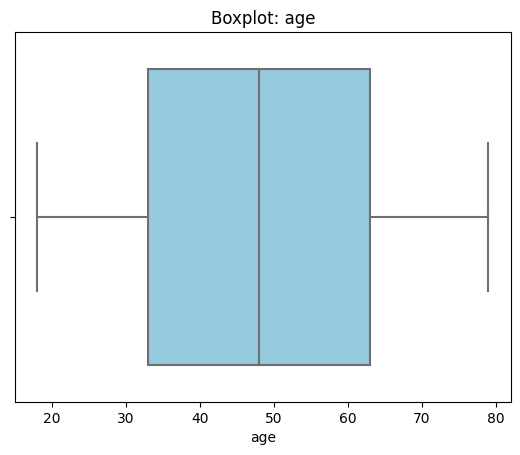

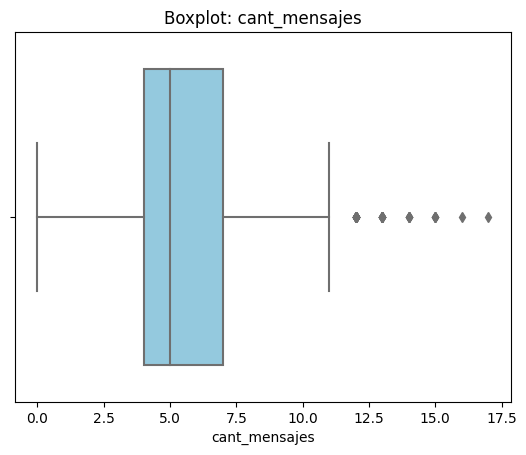

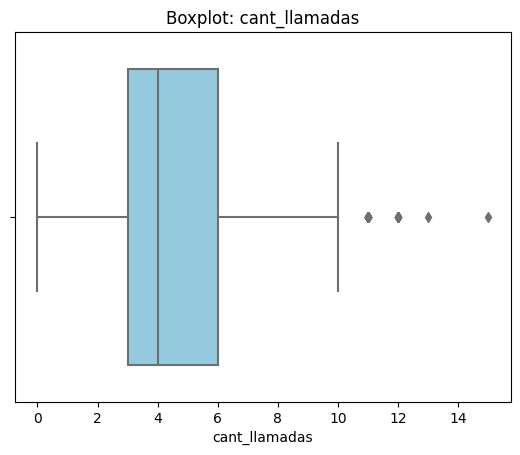

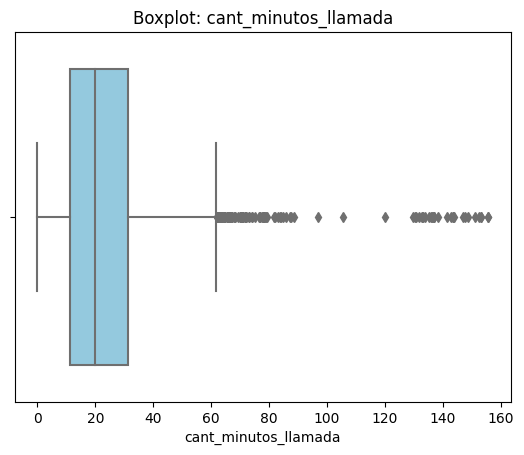

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for columna in columnas_numericas:
    plt.title(f'Boxplot: {columna}')
    sb.boxplot(user_profile[columna], color='skyblue')
    plt.show()

💡Insights: 
- Age: No muestra outliers fuera de los límites definidos por el rango intercuartílico (IQR). La distribución se encuentra concentrada dentro de los límites esperados, lo que sugiere **estabilidad** y **ausencia de valores extremos** significativos.
- cant_mensajes: La distribución presenta **ligera asimetría positiva,** evidenciada por **6 outliers** en el extremo derecho.
- cant_llamadas: La distribución presenta **ligera asimetría positiva,** evidenciada por **4 outliers** en el extremo derecho.
- cant_minutos_llamada: La distribución presenta una cola larga hacia la derecha, con **múltiples outliers superiores,** lo que indica **alta variabilidad** y presencia de **valores extremos significativos.**

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for columna in columnas_numericas:
    # IQR = Q3 - Q1
    Q1 = user_profile[columna].quantile(0.25)
    Q3 = user_profile[columna].quantile(0.75)
    
    # Calcular IQR
    IQR = Q3 - Q1
    
    # Imprimir resultado
    print(f"IQR[{columna}]: {IQR}, Extremo inferior: {Q1 - 1.5 * IQR},  Extrmo superior: {Q3 + 1.5 * IQR}")


IQR[age]: 30.0, Extremo inferior: -12.0,  Extrmo superior: 108.0
IQR[cant_mensajes]: 3.0, Extremo inferior: -0.5,  Extrmo superior: 11.5
IQR[cant_llamadas]: 3.0, Extremo inferior: -1.5,  Extrmo superior: 10.5
IQR[cant_minutos_llamada]: 20.295, Extremo inferior: -19.322500000000005,  Extrmo superior: 61.8575


In [36]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no

user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
Medir cuántos IQRs por encima del tercer cuartil está el valor máximo. Es decir:
Qué tan extremo es el valor máximo en términos de dispersión robusta.
    (Max - Q3) / IQR

Qué tan extremo es el valor máximo en términos de dispersión robusta.
- cant_mensajes: **mantener los outliers,** por que:
* (17−7)/3 = 3.33 IQR desde Q3
* Media = 5.52, desviación estándar = 2.35 → 17 está alto pero no irreal.
* No es extremadamente alto.
* **Justificación profesional:** Aunque existen valores por encima del límite superior definido por el método IQR, estos son coherentes con un comportamiento intensivo de uso y no representan valores imposibles ni errores evidentes.
Es completamente plausible en comportamiento humano.
- cant_llamadas: **mantener los outliers,** por que:
* (15 − 6) / 3 = 3 IQR desde Q3
* 15 llamadas no es un valor anómalo extremo.
* Es un usuario intensivo.
* No es físicamente imposible.
* No distorsiona dramáticamente la media (4.47).
* **Justificación:** Los valores extremos observados corresponden a usuarios con alto nivel de actividad y se consideran comportamientos válidos dentro del modelo de negocio.
- cant_minutos_llamada: **No mantener los outliers,** por que:
* (155.69 − 31.415) / 20.295 ≈ 6.1 IQR
* Este valor sí es extremo.
* Media = 23.31
* Desviación estándar = 18.16
* 155.69 está más de 7 desviaciones estándar arriba.
* Sesgo fuerte hacia la derecha.
* Posible error o caso muy raro.
* **Justificación:** Podría ser un error del sistema y además al ser valores extremos, causan cambios en las mediciones grupales, al eliminarlos tendremos una mejor visión de los registros más comunes

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# funcion para clasificar el nivel de uso del usuario
def clasificar_uso(row):
    # obtenemos los valores del usuario
    llamadas = row["cant_llamadas"]
    mensajes = row["cant_mensajes"]

    # evaluamos los valores del usuario y retornamos el valor deseado a la columna "grupo_uso"
    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"
    
    elif llamadas < 10 and mensajes < 10:
        return "Uso medio"
    
    else:
        return "Alto uso"

# Crear columna grupo_uso, Aplicar función al dataframe, fila por fila: axis=1
user_profile["grupo_uso"] = user_profile.apply(clasificar_uso, axis=1)

In [38]:
# verificar cambios
user_profile.head() 

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,"[30, 40)",Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,"[50, 60)",Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,"[50, 60)",Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,"[60, 70)",Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,"[60, 70)",Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
def clasificar_edad(row):
    edad = row['age']
    
    if edad < 30:
        return "Joven"
    
    elif edad < 60:
        return "Adulto"
    
    else:
        return "Adulto Mayor"

# Crear columna grupo_edad
user_profile["grupo_edad"] = user_profile.apply(clasificar_edad, axis=1)

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor,Bajo uso


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

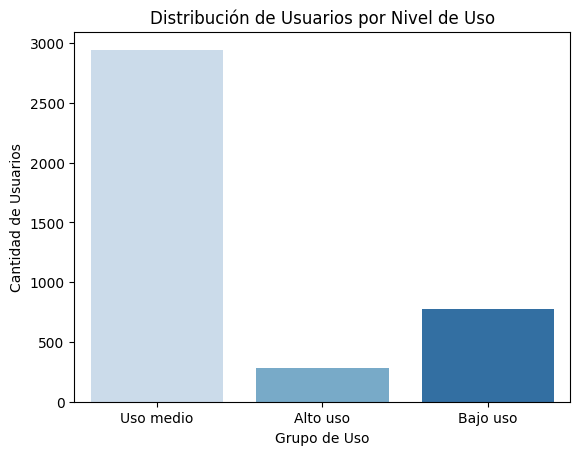

In [41]:
# Visualización de los segmentos por uso
sb.countplot(
    data=user_profile,
    x="grupo_uso",
    palette="Blues"
)

plt.title("Distribución de Usuarios por Nivel de Uso")
plt.xlabel("Grupo de Uso")
plt.ylabel("Cantidad de Usuarios")

plt.show()

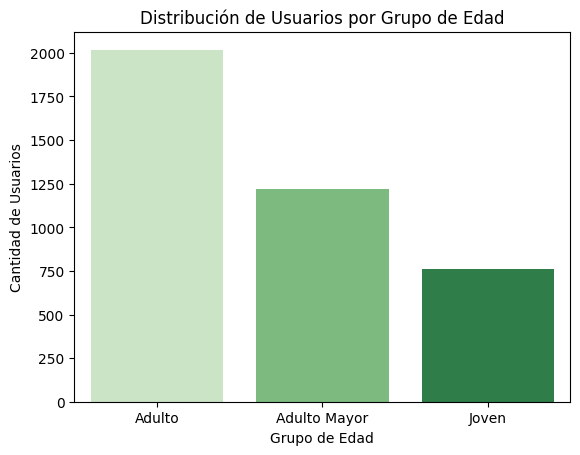

In [42]:
# Visualización de los segmentos por edad
sb.countplot(
    data=user_profile,
    x="grupo_edad",
    palette="Greens"
)

plt.title("Distribución de Usuarios por Grupo de Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("Cantidad de Usuarios")

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

* Durante la fase de exploración se identificaron los siguientes puntos:
* Analizar: ciudades con valor "?" y los churn_date como se estan ingresando, por que se estan guardando como NaN (NotANomber) en la tabla users
* No hay una relacion entre "call" - "length" y "text" - "duration", por lo tanto, se esta ingresando valores nulos NaN.
* En la tabla users, el atributo churn_date muestra un 88.35% de datos nulos, con la falta de informacion/documentacion recomiendo ignorar ese atributo para el analisis y usarlo en el futuro.
* En la tabla users, en el atributo city, se tedectan campos con el simbolo '?', un campo dificil de imputar con una proporcion del 11.72%, por lo tanto, recomiendo ignorar o dejar como nulo para el analisis por ubicacion.
* En la tabla usage, dependiendo el tipo text/call se utiliza el atributo duration para call y length para text, lo que causa muchos datos nulos NaN, 55.19% campos nulos en duration y 44.74% en length, recomiendo ignorar un campo para cada caso en su analisis o generar una nueva tabla para el tipo de uso.
* **Recomendación:** Validar valores límite con reglas de negocio.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
* Jóvenes (< 30 años)
Mayor tendencia hacia uso medio y alto.
Más activos en envío de mensajes / menor intencidad en llamadas.
Mayor dinamismo en el consumo.
* Adultos (30–59 años)
Segmento más numeroso.
Distribución equilibrada entre uso bajo y medio.
Consumo estable y predecible.
* Adultos Mayores (60+)
Mayor concentración en uso bajo.
Menor intensidad en mensajes/ Mayor intencidad en llamadas.
Mayor concentración en el plan Premium.
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
* Adultos (30–59 años) de Uso Medio
Segmento más valioso por volumen y estabilidad.
Representan el mayor porcentaje de la base de clientes.
Consumo equilibrado y predecible.
Menor volatilidad en patrones de uso.
Alta probabilidad de permanencia (retención).
**Valor estratégico:**
Son la base sólida del negocio. Su estabilidad permite ingresos recurrentes y planificación financiera más precisa.
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Fuerte asimetría positiva en **minutos de llamada**
El valor máximo de minutos se encuentra más de **6 IQR** por encima del tercer cuartil.
Existe un pequeño grupo de usuarios con consumo significativamente superior al promedio.
La media (23 min) es considerablemente menor que el máximo observado (155 min).
Esto indica presencia de heavy users reales, no errores de captura.
Los patrones de uso extremo no representan errores, sino evidencia de un segmento de alto valor.
* Estos usuarios:
**Incrementan el ingreso** promedio por cliente.
Justifican la **creación de planes** diferenciados.
Representan **oportunidad de crecimiento** sin necesidad de adquirir nuevos clientes.
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
* Crear un Plan Premium para Heavy Users
**Dirigido a:**
Usuarios de alto consumo (outliers en minutos y llamadas).
* Optimizar el Plan Intermedio (Uso Medio)
**Dirigido a:**
Adultos de uso medio (segmento más numeroso).
* Crear un Plan Económico Simplificado
**Dirigido a:**
Adultos mayores y usuarios de bajo uso.
* Diseñar Planes Segmentados por Edad + Uso o por Estrategia de Up-Selling Automatizada
**Dirigido a:**
Usuarios que constantemente se acercan al límite de su plan.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores extremos (outliers), especialmente en la variable de minutos de llamada, con fuerte asimetría positiva.
- Algunos indicadores muestran alta dispersión, lo que afecta métricas como la media y evidencia heterogeneidad en el comportamiento de los usuarios.


🔍 **Segmentos por Edad**
- Jóvenes (<30 años): Mayor dinamismo y tendencia a uso medio–alto, especialmente en mensajes.
- Adultos (30–59 años): Segmento más numeroso y estable, con consumo equilibrado.
- Adultos Mayores (60+): Mayor concentración en bajo uso, comportamiento más conservador y usuarios valiosos al ser el sector con más planes Premium. 


📊 **Segmentos por Nivel de Uso**
- Bajo uso: Clientes sensibles al precio y con consumo limitado.
- Uso medio: Núcleo más estable y representativo del negocio.
- Alto uso: Segmento minoritario pero altamente rentable, con consumo significativamente superior al promedio.


➡️ Esto sugiere que:
- Existen perfiles claramente diferenciados por edad y comportamiento.
- Los heavy users representan una oportunidad de monetización.
- El segmento medio garantiza estabilidad y volumen.
- Se requiere una estrategia de segmentación más precisa y orientada a valor.


💡 **Recomendaciones**
- Diseñar planes diferenciados (Premium, Intermedio optimizado y Básico económico) alineados a patrones reales de consumo.
- Implementar estrategias de upselling para usuarios de alto uso y fidelización para el segmento medio. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`